In [2]:
import pandas as pd
import numpy as np

# Load the dataframe
df = pd.read_csv('all_observable.csv')

# Inspect the columns to confirm parameter names
print(df.columns)
print(df.head())

# Define the function to calculate gradients based on the user's specific logic
def calculate_gradients(df):
    results = []
    
    # Get list of parameter columns (param_0, param_1, ...)
    param_cols = [col for col in df.columns if col.startswith('param_')]
    
    # Group by 'observable'
    grouped = df.groupby('observable')
    
    for observable, group_data in grouped:
        for param in param_cols:
            # 1. Sort by the focused parameter
            sorted_data = group_data.sort_values(by=param)
            
            # Get the arrays for calculation
            energies = sorted_data['ideal_energy'].values
            param_values = sorted_data[param].values
            
            # 2. Calculate differences (FDM step)
            # diff(arr) calculates arr[n+1] - arr[n]
            d_energy = np.diff(energies)
            d_param = np.diff(param_values)
            
            # Avoid division by zero: filter out steps where parameter didn't change (d_param == 0)
            # This happens if there are duplicate parameter values in the sort order
            valid_indices = d_param != 0
            
            if np.any(valid_indices):
                # Calculate gradients: dE / dP
                gradients = d_energy[valid_indices] / d_param[valid_indices]
                
                # Calculate average gradient
                avg_gradient = np.mean(gradients)
            else:
                avg_gradient = 0 # or np.nan if preferred, but 0 implies no change measurable
            
            results.append({
                'observable': observable,
                'parameter': param,
                'avg_gradient_ideal': avg_gradient
            })
            
    return pd.DataFrame(results)

# Execute calculation
gradient_df = calculate_gradients(df)

Index(['Unnamed: 0', 'noisy_energy', 'ideal_energy', 'zne_energy',
       'observable', 'param_0', 'param_1', 'param_2', 'param_3', 'param_4',
       'param_5', 'param_6', 'param_7', 'param_8', 'param_9', 'param_10',
       'param_11', 'dataset'],
      dtype='object')
   Unnamed: 0  noisy_energy  ideal_energy  zne_energy observable   param_0  \
0           0      1.008633      1.007154    0.969554       IIII  4.585044   
1           1      1.020991      1.013854    1.015758       IIII  2.690355   
2           2      1.002596      1.005501    0.986206       IIII -1.019573   
3           3      0.997879      1.011975    1.006947       IIII  0.994827   
4           4      1.010382      0.997144    1.019944       IIII  0.025253   

    param_1   param_2   param_3   param_4   param_5   param_6   param_7  \
0 -3.033315  1.291780  3.322724  1.214280  0.562384  0.143545  1.019945   
1 -0.569497 -3.420634  0.672669 -0.304713 -4.858652  3.558932 -4.625520   
2 -1.710576 -4.967441  1.219015 -3.7

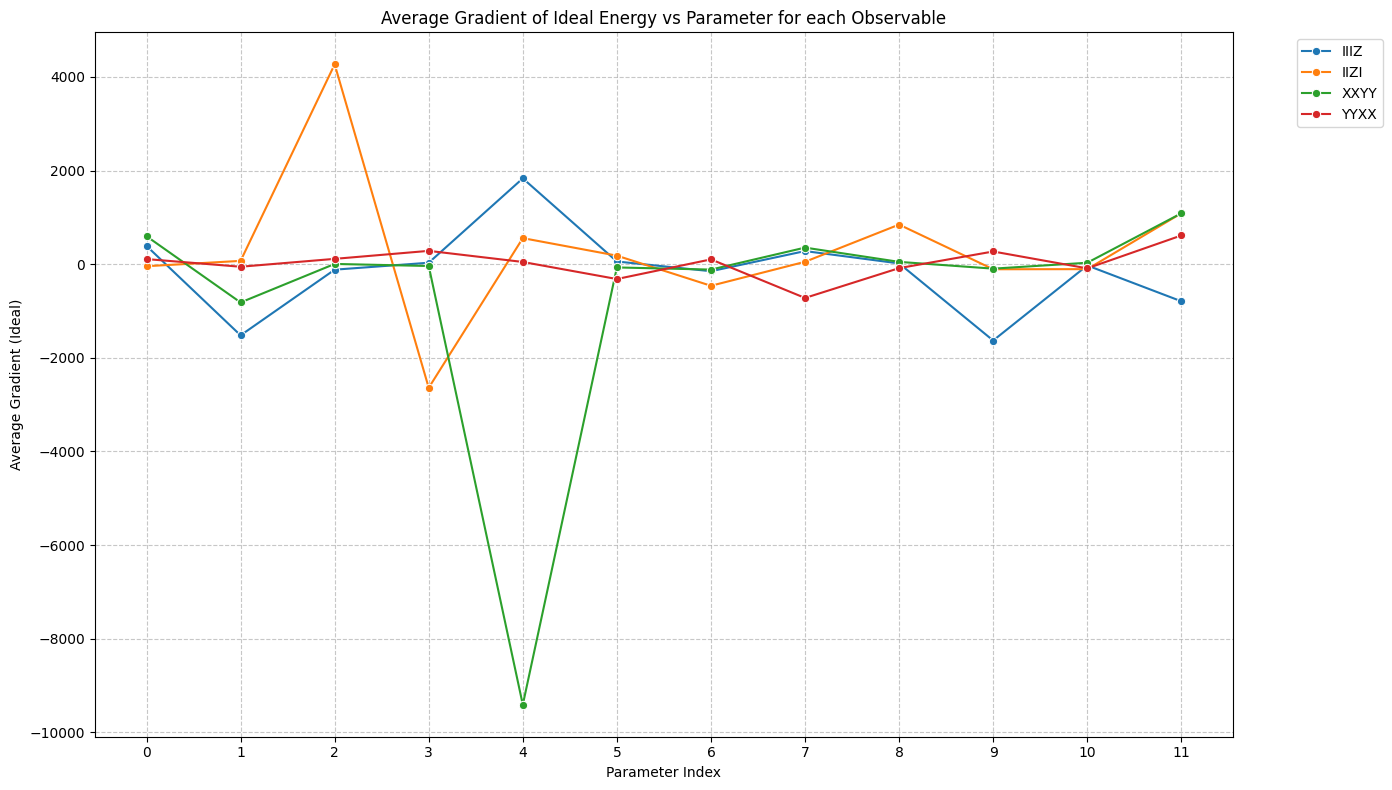

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
gradient_df = gradient_df[gradient_df['observable'].isin(['IIIZ','IIZI','XXYY' , 'YYXX'])]

# Extract parameter index for proper sorting and plotting
# Assuming format 'param_X'
gradient_df['param_idx'] = gradient_df['parameter'].apply(lambda x: int(re.search(r'\d+', x).group()))

# Sort the dataframe by observable and parameter index
gradient_df = gradient_df.sort_values(by=['observable', 'param_idx'])

# Create the plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=gradient_df, x='param_idx', y='avg_gradient_ideal', hue='observable', marker='o')

# Customize the plot
plt.title('Average Gradient of Ideal Energy vs Parameter for each Observable')
plt.xlabel('Parameter Index')
plt.ylabel('Average Gradient (Ideal)')
plt.xticks(gradient_df['param_idx'].unique())  # Ensure all parameter indices are shown
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside

# Adjust layout to prevent clipping
plt.tight_layout()

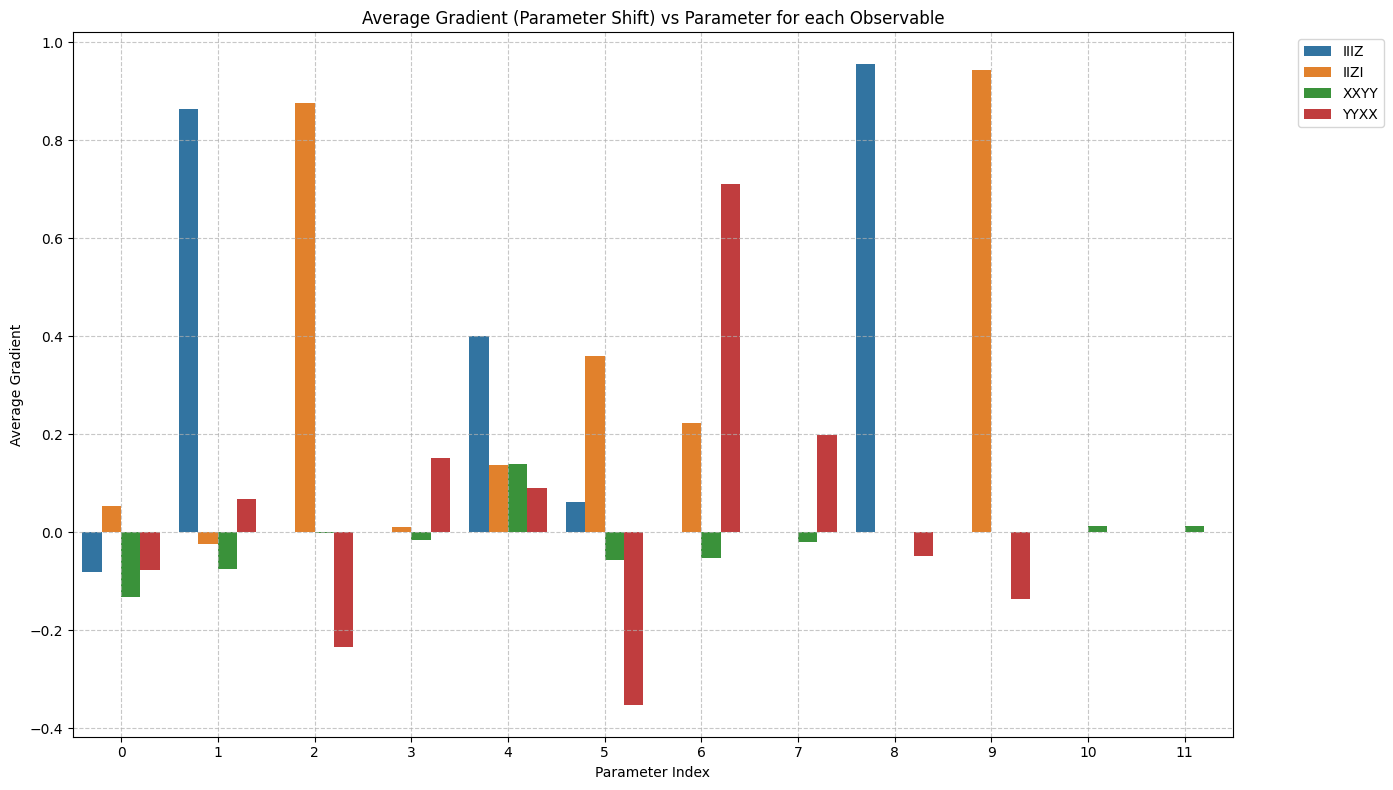

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the new dataset
df_param_shift = pd.read_csv('parameter_shift_results_fast.csv')
df_param_shift = df_param_shift[df_param_shift['observable'].isin(['IIIZ','IIZI','XXYY','YYXX'])]

# Identify gradient columns
grad_cols = [col for col in df_param_shift.columns if col.startswith('grad_param_')]

# Group by 'observable' and calculate the mean of the gradient columns
# We ignore other columns like 'dataset', 'input_val', 'ideal_energy' for the average as requested
grouped_avg = df_param_shift.groupby('observable')[grad_cols].mean().reset_index()

# Melt the dataframe to long format for plotting
# Variables: observable, variable (param name), value (avg gradient)
melted_df = grouped_avg.melt(id_vars='observable', value_vars=grad_cols, 
                             var_name='parameter_col', value_name='avg_gradient')

# Extract parameter index from column name (e.g., 'grad_param_0' -> 0)
melted_df['param_idx'] = melted_df['parameter_col'].apply(lambda x: int(re.search(r'\d+', x).group()))

# Sort for plotting
melted_df = melted_df.sort_values(by=['observable', 'param_idx'])

# Plotting
plt.figure(figsize=(14, 8))
sns.barplot(data=melted_df, x='param_idx', y='avg_gradient', hue='observable')

# Customize the plot
plt.title('Average Gradient (Parameter Shift) vs Parameter for each Observable')
plt.xlabel('Parameter Index')
plt.ylabel('Average Gradient')
plt.xticks(sorted(melted_df['param_idx'].unique()))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

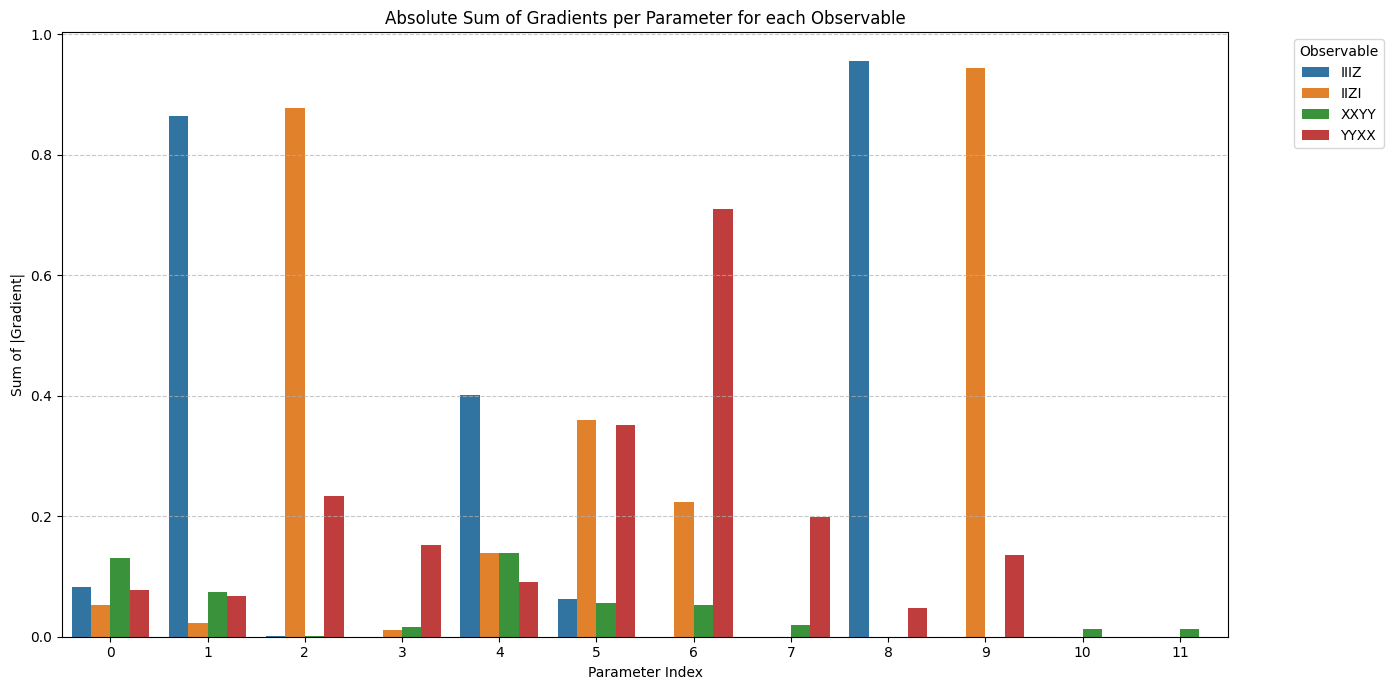

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Load dataset
df_param_shift = pd.read_csv('parameter_shift_results_fast.csv')
# Filter observable yang diinginkan
df_filtered = df_param_shift[df_param_shift['observable'].isin(['IIIZ', 'XXYY', 'YYXX', 'IIZI']
)]

# 2. Identifikasi kolom gradien
grad_cols = [col for col in df_filtered.columns if col.startswith('grad_param_')]

# 3. Hitung Absolute Sum Gradient per Parameter untuk masing-masing Observable
# Kita menghitung jumlah dari nilai absolut gradien di seluruh baris data
abs_sum_df = df_filtered.groupby('observable')[grad_cols].apply(lambda x: x.sum().abs()).reset_index()

# 4. Transformasi data ke format long (melted) untuk plotting
melted_abs_sum = abs_sum_df.melt(id_vars='observable', value_vars=grad_cols, 
                                var_name='parameter_col', value_name='abs_sum_gradient')

# Ekstrak indeks parameter (misal: 'grad_param_0' -> 0)
melted_abs_sum['param_idx'] = melted_abs_sum['parameter_col'].apply(lambda x: int(re.search(r'\d+', x).group()))
melted_abs_sum = melted_abs_sum.sort_values(by=['observable', 'param_idx'])

# --- Visualisasi ---

# Plot 1: Bar Chart (Histogram-like) Absolute Sum Gradient per Parameter
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_abs_sum, x='param_idx', y='abs_sum_gradient', hue='observable')

plt.title('Absolute Sum of Gradients per Parameter for each Observable')
plt.xlabel('Parameter Index')
plt.ylabel('Sum of |Gradient|')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Observable', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


plt.show()

Total Absolute Gradient per Observable:
  observable  total_absolute_gradient
1       IIZI                 2.629737
0       IIIZ                 2.365747
3       YYXX                 2.065912
2       XXYY                 0.516692


/tmp/ipykernel_14552/2725860339.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_grad_per_obs, x='observable', y='total_absolute_gradient', palette="flare")


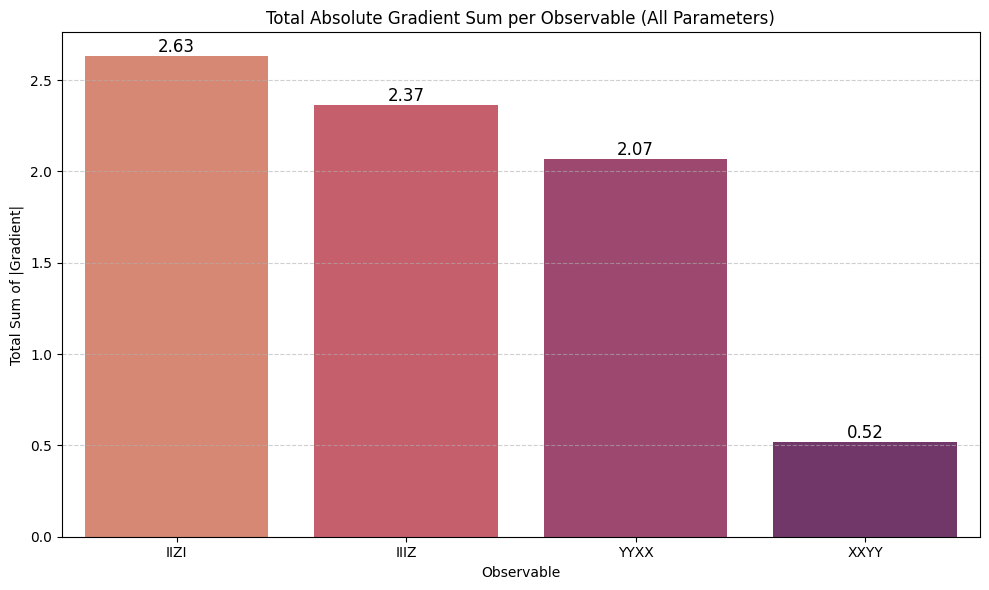

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by observable and sum the gradients across all parameters
total_grad_per_obs = melted_abs_sum.groupby('observable')['abs_sum_gradient'].sum().reset_index()
total_grad_per_obs.columns = ['observable', 'total_absolute_gradient']

# Sort for better visualization
total_grad_per_obs = total_grad_per_obs.sort_values(by='total_absolute_gradient', ascending=False)

print("Total Absolute Gradient per Observable:")
print(total_grad_per_obs)
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=total_grad_per_obs, x='observable', y='total_absolute_gradient', palette="flare")

# Add values on top of bars
for i, val in enumerate(total_grad_per_obs['total_absolute_gradient']):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=12)

plt.title('Total Absolute Gradient Sum per Observable (All Parameters)')
plt.xlabel('Observable')
plt.ylabel('Total Sum of |Gradient|')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()